In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load dataset
df_raw = pd.read_csv('data/classification_bonus_practice_data.csv')
df_raw.columns = df_raw.columns.str.strip()

print(f"Dataset Shape: {df_raw.shape}")
print("\nFirst 5 rows:")
display(df_raw.head())

print("\nData Types & Missing Values:")
print(df_raw.info())

Dataset Shape: (15000, 16)

First 5 rows:


,ID,Survive,Gender,Smoke,Diabetes,Age,Ejection Fraction,Sodium,Creatinine,Platelets,Creatine phosphokinase,Blood Pressure,Hemoglobin,Height,Weight,Favorite color
0,TIG1GE,0,Male,Yes,Normal,50,Low,141,0.7,266000.0,185,105,12.3,180,93,green
1,VXUCV9,1,Male,No,Normal,75,Low,134,2.5,224000.0,99,162,13.0,140,47,black
2,AFH4F1,1,Female,No,Pre-diabetes,80,Low,135,1.3,192000.0,776,179,12.4,150,61,white
3,ZK6PAC,0,Male,No,Normal,-60,Low,136,0.9,228000.0,2261,136,15.3,130,48,yellow
4,6CVBRT,0,Female,No,Normal,70,Low,141,0.9,358000.0,1202,171,13.3,177,64,blue



Data Types & Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      15000 non-null  str    
 1   Survive                 15000 non-null  str    
 2   Gender                  15000 non-null  str    
 3   Smoke                   15000 non-null  str    
 4   Diabetes                15000 non-null  str    
 5   Age                     15000 non-null  int64  
 6   Ejection Fraction       15000 non-null  str    
 7   Sodium                  15000 non-null  int64  
 8   Creatinine              14501 non-null  float64
 9   Platelets               15000 non-null  float64
 10  Creatine phosphokinase  15000 non-null  int64  
 11  Blood Pressure          15000 non-null  int64  
 12  Hemoglobin              15000 non-null  float64
 13  Height                  15000 non-null  int64  
 14  Weight             

In [4]:
df = df_raw.copy()

# 1. Clean Age (remove erroneous negative values)
df = df[df['Age'] > 0]

# 2. Standardize 'Survive' column (1, 0, yes, no, etc.)
survive_map = {'1': 1, '1.0': 1, 'yes': 1, 'true': 1, '0': 0, '0.0': 0, 'no': 0, 'false': 0}
df['Survive'] = df['Survive'].astype(str).str.strip().str.lower().map(survive_map)

# 3. Clean 'Ejection Fraction' (strip % and convert to float)
if 'Ejection Fraction' in df.columns and df['Ejection Fraction'].dtype == 'O':
    df['Ejection Fraction'] = pd.to_numeric(
        df['Ejection Fraction'].astype(str).str.replace('%', '').str.strip(), 
        errors='coerce'
    )

# 4. Standardize other binary features (Smoke, Diabetes, Gender)
binary_map = {'yes': 1, 'no': 0, '1': 1, '0': 0, 'male': 1, 'm': 1, 'female': 0, 'f': 0}
for col in ['Smoke', 'Diabetes', 'Gender']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().map(binary_map)

# 5. Impute missing Creatinine with median
if 'Creatinine' in df.columns:
    imputer = SimpleImputer(strategy='median')
    df['Creatinine'] = imputer.fit_transform(df[['Creatinine']])

# 6. Drop uninformative identifier/noise columns
df = df.drop(columns=['ID', 'Favorite color'], errors='ignore')

# Downcast memory usage
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype(np.float32)
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype(np.int16)

print("Data Cleaning Complete. Remaining Missing Values:")
print(df.isnull().sum())

Data Cleaning Complete. Remaining Missing Values:
Survive                       0
Gender                        0
Smoke                         0
Diabetes                  14570
Age                           0
Ejection Fraction             0
Sodium                        0
Creatinine                    0
Platelets                     0
Creatine phosphokinase        0
Blood Pressure                0
Hemoglobin                    0
Height                        0
Weight                        0
dtype: int64


/tmp/ipykernel_1865/2072915070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Survive', palette='Set2')


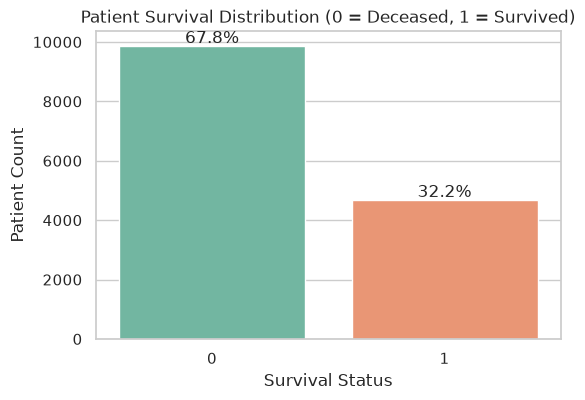

In [5]:
# Class Balance Check
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Survive', palette='Set2')
plt.title("Patient Survival Distribution (0 = Deceased, 1 = Survived)")
plt.xlabel("Survival Status")
plt.ylabel("Patient Count")

# Add percentages on bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

In [ ]:
# Analyze distributions of key numerical features across Survival status
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x='Survive', y='Age', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title("Age vs. Survival")

sns.boxplot(data=df, x='Survive', y='Creatinine', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title("Serum Creatinine vs. Survival")

sns.boxplot(data=df, x='Survive', y='Ejection Fraction', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title("Ejection Fraction vs. Survival")

sns.boxplot(data=df, x='Survive', y='Blood Pressure', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title("Blood Pressure vs. Survival")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()